# LightGBM Combined Pipeline — Hold-out Test on **All Records**

Evaluates the combined two-stage pipeline (Stage 1 wet/dry classifier × Stage 2 quantile
regressors) on the **492 holdout stations**, but over the **entire** 1961–2023 record set
instead of the wet subset only. This produces the *All records* CRPS / MAE numbers that
feed Chapter 7's cross-method comparison table.

**Pipeline:**
1. Stage 1 (`LGBMClassifier`, 6 features) predicts $\hat{p}_{\mathrm{wet}}$.
2. A station-day is classified **wet** if $\hat{p}_{\mathrm{wet}} > 0.4$ (Hofstra 2008 threshold).
3. Wet-classified records get Stage 2 features (32) and the 11 quantile boosters.
4. Dry-classified records get an **ensemble of 11 zeros** — a degenerate distribution at 0 mm.
5. `properscoring.crps_ensemble` is applied to the unified 11.3M × 11 ensemble matrix — it
   handles the degenerate-at-zero case automatically (CRPS reduces to $|Z|$ on those rows).

**Reusable artefacts:**
- `s3://thesis-data-ismaktam/lgbm/final/models.joblib` — Stage 2 boosters (downloaded once).
- `results/lgbm/stage_1/lgbm_stage1_final.joblib` — Stage 1 final model (local).
- `outputs/holdout_station_ids.json` — 492 canonical holdout IDs.
- Stage 2 geo-features are only computed for the wet-classified subset (≈4 M rows) — Stage 1
  filters out the dry ≈7 M rows that don't need the expensive 32-feature compute.

## 0. Imports

In [1]:
import sys, os, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import joblib
import properscoring as ps
import boto3
from botocore.exceptions import ClientError
from joblib import Parallel, delayed
from sklearn.neighbors import BallTree

warnings.filterwarnings('ignore')

ROOT = Path('../..')
sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)

from thesis.config import Config
from thesis.data.registry import DataRegistry
from thesis.transforms import ProjectionTransform, IndicatorTransform
from thesis.transforms.pipeline import TransformPipeline
from thesis.scripts.run_grk_kfold_cv import SOIL_VARS
from thesis.models.grk.features import compute_day_geo_features

print(f'Working dir:  {Path.cwd()}')
print(f'LightGBM:     {lgb.__version__}')
print(f'CPU threads:  {os.cpu_count()}')

/app/.venv/lib/python3.12/site-packages/properscoring/_crps.py:257: SyntaxWarning: invalid escape sequence '\i'
  CRPS(F, x) = \int_z (F(z) - H(z - x))^2 dz
/app/.venv/lib/python3.12/site-packages/properscoring/_brier.py:10: SyntaxWarning: invalid escape sequence '\i'
  The Brier score (BS) scores binary forecasts $k \in \{0, 1\}$,
/app/.venv/lib/python3.12/site-packages/properscoring/_brier.py:102: SyntaxWarning: invalid escape sequence '\i'
  CRPS(F, x) = \int_z BS(F(z), H(z - x)) dz


Working dir:  /root/precip_interpolation_thesis
LightGBM:     4.5.0
CPU threads:  128


## 1. Paths + S3 helper

In [2]:
S3_BUCKET = 'thesis-data-ismaktam'
S3_FINAL  = 'lgbm/final'

CACHE_DIR = Path('results/lgbm')
FINAL_DIR = CACHE_DIR / 'final'
STAGE1_DIR = CACHE_DIR / 'stage_1'
FIG_DIR   = Path('outputs/lgbm_test_all_records')
for d in (CACHE_DIR, FINAL_DIR, STAGE1_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

HOLDOUT_JSON = Path('outputs/holdout_station_ids.json')
HOLDOUT_IDS  = set(json.loads(HOLDOUT_JSON.read_text()))

# Stage 2 constants (must match lgbm_train.ipynb)
K_GEO         = 15
SVD_QUANTILES = np.arange(0.0, 1.05, 0.05)
TARGET_COL    = 'precip_mm'

# Stage 1 constants (must match lgbm_stage1.ipynb section 13)
K_STAGE1      = 50
STAGE1_FEATS  = ['x_proj', 'y_proj', 'elevation_m',
                  'global_wet_frac', 'knn_wet_frac', 'knn_mean_dist_km']
WET_THRESHOLD_PROB = 0.40   # P(rain) decision threshold; matches Hofstra (2008) / OK pipeline

s3 = boto3.client('s3')
def s3_get(key, local, force=False):
    if local.exists() and not force:
        return local
    local.parent.mkdir(parents=True, exist_ok=True)
    s3.download_file(S3_BUCKET, key, str(local))
    print(f'  ↓ {key}  ({local.stat().st_size / 1e6:.1f} MB)')
    return local

print(f'Holdout:      {len(HOLDOUT_IDS)} stations')

Holdout:      492 stations


## 2. Load both models

- **Stage 1**: local `results/lgbm/stage_1/lgbm_stage1_final.joblib` (binary `LGBMClassifier`).
- **Stage 2**: `s3://thesis-data-ismaktam/lgbm/final/models.joblib` (11 quantile boosters).

In [5]:
print('Downloading Stage 1 final model ...')
s3_get(f'{S3_FINAL}/stage1.joblib', FINAL_DIR / 'stage1.joblib')
stage1 = joblib.load(FINAL_DIR / 'stage1.joblib')
print(f'Stage 1 loaded: {type(stage1).__name__}, n_trees={stage1.booster_.num_trees()}')

print('Downloading Stage 2 final model ...')
s3_get(f'{S3_FINAL}/models.joblib', FINAL_DIR / 'models.joblib')
saved        = joblib.load(FINAL_DIR / 'models.joblib')
BOOSTERS     = saved['models']
QUANTILES    = list(saved['quantiles'])
FEATURE_COLS = list(saved['feature_cols'])
print(f'Stage 2: {len(QUANTILES)} quantile boosters, {len(FEATURE_COLS)} features')
Q_IDX_50 = QUANTILES.index(0.50)

  ↓ lgbm/final/stage1.joblib  (7.1 MB)
Stage 1 loaded: LGBMClassifier, n_trees=1000
  ↓ lgbm/final/models.joblib  (212.4 MB)
Stage 2: 11 quantile boosters, 32 features


## 3. Load all stations × all dates

`exclude_holdout=False` returns train + holdout. We flag holdout rows and keep the
**full record set** (no wet-day filter), since the goal of this notebook is exactly the
*All records* metric.

In [6]:
cfg      = Config()
registry = DataRegistry.from_config(cfg)

print(f'Date range: {cfg.date_start} → {cfg.date_end}')
all_raw  = registry.stations.load(cfg.date_start, cfg.date_end, exclude_holdout=False)
pipeline = TransformPipeline([
    ProjectionTransform(target_crs=cfg.study_area.target_crs),
    IndicatorTransform(threshold_mm=cfg.wet_day_threshold_mm),
])
all_proc = pipeline.fit_transform(all_raw)
all_proc['is_holdout'] = all_proc['station_id'].isin(HOLDOUT_IDS)

station_meta = (
    all_proc
    .drop_duplicates('station_id')[['station_id', 'x_proj', 'y_proj',
                                     'elevation_m', 'is_holdout']]
    .reset_index(drop=True)
)
n_train_st = (~station_meta['is_holdout']).sum()
n_test_st  =   station_meta['is_holdout'].sum()
print(f'All records: {len(all_proc):,}   '
      f'(holdout={int(all_proc["is_holdout"].sum()):,}, '
      f'train={int((~all_proc["is_holdout"]).sum()):,})')
print(f'Stations:    {len(station_meta):,}   (train={n_train_st}, holdout={n_test_st})')

Date range: 1961-01-01 → 2023-12-31
All records: 56,558,580   (holdout=11,320,920, train=45,237,660)
Stations:    2,458   (train=1966, holdout=492)


## 4. Stage 1 features for holdout × all dates

Stage 1 needs three derived features:
- `global_wet_frac` — fraction of *train* stations wet on the date.
- `knn_wet_frac`    — mean indicator of the $K=50$ nearest *train* neighbours that day.
- `knn_mean_dist_km` — mean distance to those neighbours.

Critical: the neighbour pool is **train stations only**. The same contract the model was
trained under.

In [7]:
train_meta = station_meta[~station_meta['is_holdout']].reset_index(drop=True)
test_meta  = station_meta[ station_meta['is_holdout']].reset_index(drop=True)

# `global_wet_frac` is built over train rows only
train_proc = all_proc[~all_proc['is_holdout']]
gwf = (
    train_proc.groupby('date')['rain_indicator']
    .mean().rename('global_wet_frac').reset_index()
)
print(f'global_wet_frac:  {gwf.shape}')

# Build a (date × train_station) pivot of the wet indicator, used to derive
# `knn_wet_frac` per holdout station per day.
pivot_train = (
    train_proc[['date', 'station_id', 'rain_indicator']]
    .pivot_table(index='date', columns='station_id',
                  values='rain_indicator', aggfunc='first')
)
print(f'pivot_train:      {pivot_train.shape}')

# K nearest train neighbours for every holdout station (one BallTree query)
tree = BallTree(train_meta[['x_proj', 'y_proj']].values, metric='euclidean')
dist_m, idx = tree.query(test_meta[['x_proj', 'y_proj']].values, k=K_STAGE1)

n_test = len(test_meta)
wet_mat = np.zeros((n_test, len(pivot_train)), dtype=np.float32)
knn_dist_km = np.zeros(n_test, dtype=np.float32)
for i in range(n_test):
    nbr_sids = train_meta['station_id'].values[idx[i]]
    valid    = [s for s in nbr_sids if s in pivot_train.columns]
    if valid:
        wet_mat[i] = pivot_train[valid].mean(axis=1).values
    knn_dist_km[i] = dist_m[i].mean() / 1000

knn_wet_df = (
    pd.DataFrame(wet_mat.T, index=pivot_train.index,
                  columns=test_meta['station_id'].values)
    .reset_index()
    .melt(id_vars='date', var_name='station_id', value_name='knn_wet_frac')
)
knn_dist_df = pd.DataFrame({
    'station_id':       test_meta['station_id'].values,
    'knn_mean_dist_km': knn_dist_km,
})

df_stage1 = (
    all_proc[all_proc['is_holdout']]
    [['date', 'station_id', 'x_proj', 'y_proj', 'elevation_m',
      'precip_mm', 'rain_indicator']]
    .merge(gwf,          on='date',                 how='left')
    .merge(knn_wet_df,   on=['date', 'station_id'], how='left')
    .merge(knn_dist_df,  on='station_id',           how='left')
    .reset_index(drop=True)
)
# Drop rows with missing core fields (e.g. station-day gaps), if any
df_stage1 = df_stage1.dropna(subset=STAGE1_FEATS).reset_index(drop=True)
print(f'df_stage1: {df_stage1.shape}   NaN(feat)={int(df_stage1[STAGE1_FEATS].isna().any(axis=1).sum())}')
del wet_mat, pivot_train

global_wet_frac:  (23010, 2)
pivot_train:      (23010, 1966)
df_stage1: (11320920, 10)   NaN(feat)=0


## 5. Run Stage 1 → wet/dry mask

Threshold $\hat{p}_{\mathrm{wet}} > 0.40$ (Hofstra 2008). Wet-classified rows flow into
Stage 2; dry rows get the zero ensemble.

In [9]:
X_s1 = df_stage1[STAGE1_FEATS].values.astype(np.float32)
print(f'Predicting Stage 1 on {len(X_s1):,} rows ...')
t0 = time.time()
try:
    # Preferred path (sklearn API)
    df_stage1['p_wet'] = stage1.predict_proba(X_s1)[:, 1].astype(np.float32)
except TypeError as e:
    # Compatibility fallback for sklearn/lightgbm API mismatches
    if ('force_all_finite' not in str(e)) and ('ensure_all_finite' not in str(e)):
        raise
    p = stage1.booster_.predict(X_s1, num_iteration=-1)
    if np.ndim(p) == 2:  # safety for unexpected 2D output
        p = p[:, 1]
    df_stage1['p_wet'] = np.asarray(p, dtype=np.float32)

df_stage1['p_wet'] = np.clip(df_stage1['p_wet'], 0.0, 1.0)
df_stage1['pred_wet']   = (df_stage1['p_wet'] > WET_THRESHOLD_PROB).astype(np.int8)
print(f'Done in {time.time() - t0:.1f}s')

wet_rate_obs  = df_stage1['rain_indicator'].mean()
wet_rate_pred = df_stage1['pred_wet'].mean()
print(f'Observed wet (>=0.5mm):       {wet_rate_obs:.4f}')
print(f'Predicted wet (p>{WET_THRESHOLD_PROB:.2f}):     {wet_rate_pred:.4f}')
print()
print('Confusion (observed × predicted):')
print(pd.crosstab(df_stage1['rain_indicator'].astype(int),
                   df_stage1['pred_wet'], rownames=['obs'], colnames=['pred']))

Predicting Stage 1 on 11,320,920 rows ...
Done in 634.4s
Observed wet (>=0.5mm):       0.3830
Predicted wet (p>0.40):     0.4202

Confusion (observed × predicted):
pred        0        1
obs                   
0     6354324   630719
1      209208  4126669


## 6. Stage 2 features for the wet-classified subset

The 32-feature compute (`compute_day_geo_features`) is by far the most expensive step, so it
is only run on the rows Stage 1 flagged as wet. The neighbour pool for the IDW/SVD/GOS
features is, as in `lgbm_test.ipynb`, the set of **non-holdout** stations: `train_mask =
~is_holdout`.

In [10]:
wet_keys = set(
    zip(df_stage1.loc[df_stage1['pred_wet'] == 1, 'date'],
        df_stage1.loc[df_stage1['pred_wet'] == 1, 'station_id'])
)
wet_dates = sorted({d for d, _ in wet_keys})
print(f'Stage 1 wet rows: {len(wet_keys):,}  ({len(wet_dates):,} unique days)')

# Per-day record set used by compute_day_geo_features: train stations supply Z, holdout
# queries are extracted from the same daily frame.
day_records = (
    all_proc[all_proc['date'].isin(wet_dates)]
    [['date', 'station_id', 'x_proj', 'y_proj', 'precip_mm', 'is_holdout']]
)
groups = list(day_records.groupby('date', sort=True))
print(f'Days to compute features for: {len(groups):,}')

def features_one_day(date, sub):
    if not sub['is_holdout'].any():
        return []
    train_mask = (~sub['is_holdout'].values)
    return compute_day_geo_features(
        date,
        xy_all   = sub[['x_proj', 'y_proj']].values,
        z_all    = sub['precip_mm'].values,
        sids_all = sub['station_id'].values,
        train_mask = train_mask,
        k = K_GEO,
        svd_quantiles = SVD_QUANTILES,
    )

t0   = time.time()
rows = Parallel(n_jobs=-1, backend='loky', verbose=5)(
    delayed(features_one_day)(date, grp) for date, grp in groups
)
df_geo = pd.DataFrame([r for day_recs in rows for r in day_recs])
df_geo = df_geo[df_geo['station_id'].isin(HOLDOUT_IDS)].reset_index(drop=True)
del rows
print(f'Geo features done in {time.time() - t0:.1f}s   →   df_geo: {df_geo.shape}')

Stage 1 wet rows: 4,757,388  (18,384 unique days)
Days to compute features for: 18,384


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 123 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   10.8s
[Parallel(n_jobs=-1)]: Done 204 tasks      | elapsed:   17.3s
[Parallel(n_jobs=-1)]: Done 402 tasks      | elapsed:   27.3s
[Parallel(n_jobs=-1)]: Done 636 tasks      | elapsed:   37.9s
[Parallel(n_jobs=-1)]: Done 906 tasks      | elapsed:   51.1s
[Parallel(n_jobs=-1)]: Done 1212 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 1554 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 1932 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 2346 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 2796 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 3282 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 3804 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 4362 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done 4956 tasks      | elapsed:  4.1min
[Parallel(n_jobs=-1)]: Done 5586 tasks      |

Geo features done in 1078.6s   →   df_geo: (9044928, 25)


## 7. SoilGrids static features

In [11]:
soil_rows = {'station_id': station_meta['station_id'].values}
for var, src in registry.soilgrids.items():
    if var in SOIL_VARS:
        soil_rows[var] = src.sample_at_projected(
            station_meta['x_proj'].values, station_meta['y_proj'].values,
        )
soil_static    = pd.DataFrame(soil_rows).set_index('station_id')
available_soil = [v for v in SOIL_VARS if v in soil_static.columns]
for v in available_soil:
    soil_static[v] = soil_static[v].fillna(float(soil_static[v].median()))
print(f'SoilGrids: {available_soil}')

spatial_cols = ['x_proj', 'y_proj', 'elevation_m']
geo_cols     = ['idw', 'gos'] + [f'svd_{i:02d}' for i in range(len(SVD_QUANTILES))]
buildable    = set(spatial_cols + geo_cols + available_soil)
missing      = [c for c in FEATURE_COLS if c not in buildable]
assert not missing, f'Cannot reproduce features: {missing}'
print(f'Schema check OK ({len(FEATURE_COLS)} columns reproducible)')

SoilGrids: ['bulk_density', 'clay', 'sand', 'silt', 'soc', 'water_10kpa']
Schema check OK (32 columns reproducible)


## 8. Stage 2 — predict 11 quantiles on the wet-classified subset

In [12]:
df_wet_pred = (
    df_stage1.loc[df_stage1['pred_wet'] == 1,
                   ['station_id', 'date', 'precip_mm',
                    'x_proj', 'y_proj', 'elevation_m']]
    .merge(df_geo,                            on=['station_id', 'date'], how='inner')
    .merge(soil_static[available_soil].reset_index(), on='station_id',   how='left')
    .reset_index(drop=True)
)
for v in available_soil:
    df_wet_pred[v] = df_wet_pred[v].fillna(df_wet_pred[v].median())

X_te = np.ascontiguousarray(df_wet_pred[FEATURE_COLS].values.astype(np.float32))
K    = len(QUANTILES)
print(f'X_te: {X_te.shape}   K={K}   NaN={int(np.isnan(X_te).sum())}')

t0      = time.time()
q_preds = np.empty((len(X_te), K), dtype=np.float32)
for qi, alpha in enumerate(QUANTILES):
    q_preds[:, qi] = BOOSTERS[alpha].predict(
        X_te, num_iteration=-1, n_jobs=os.cpu_count()
    ).astype(np.float32)
np.clip(q_preds, 0.0, None, out=q_preds)
q_preds.sort(axis=1)
print(f'Stage 2 prediction done in {time.time() - t0:.1f}s')

df_wet_pred[[f'q{int(a * 100):02d}' for a in QUANTILES]] = q_preds
df_wet_pred['q50_pred'] = q_preds[:, Q_IDX_50]
del X_te

X_te: (4757388, 32)   K=11   NaN=0
Stage 2 prediction done in 67.0s


## 9. Assemble the combined ensemble on **all** holdout records

Every record gets an 11-member ensemble:
- Stage 1 dry → ensemble of 11 zeros.
- Stage 1 wet → Stage 2 sorted clipped quantiles.

`ps.crps_ensemble` consumes this ($n \times 11$) matrix and the observed mm vector $Z$ and
returns the per-record CRPS. For dry-classified rows the ensemble is a point mass at 0, so
the formula collapses to $\mathrm{CRPS} = |Z|$ — full penalty if Stage 1 misclassified a wet
day, zero penalty if it correctly predicted a dry day.

In [13]:
df_all = df_stage1[['station_id', 'date', 'precip_mm', 'rain_indicator',
                     'p_wet', 'pred_wet']].copy()

ensemble = np.zeros((len(df_all), K), dtype=np.float32)
q50_pred = np.zeros(len(df_all), dtype=np.float32)

# Map (station_id, date) → row index for fast assignment of the wet-classified subset
df_all_idx = pd.MultiIndex.from_arrays(
    [df_all['station_id'].values, df_all['date'].values]
)
wet_idx = pd.MultiIndex.from_arrays(
    [df_wet_pred['station_id'].values, df_wet_pred['date'].values]
)
row_pos = df_all_idx.get_indexer(wet_idx)
assert (row_pos >= 0).all(), 'Stage 2 row not found in df_stage1 — pipeline desync'

q_cols = [f'q{int(a * 100):02d}' for a in QUANTILES]
ensemble[row_pos] = df_wet_pred[q_cols].values
q50_pred[row_pos] = df_wet_pred['q50_pred'].values
df_all['q50_pred'] = q50_pred

# Sanity: dry rows must be exactly zero
dry_rows = (df_all['pred_wet'] == 0).values
assert (ensemble[dry_rows] == 0).all(), 'Dry row got non-zero ensemble!'
print(f'Ensemble shape: {ensemble.shape}')
print(f'  zero-ensemble rows (Stage1 dry): {int(dry_rows.sum()):,}')
print(f'  Stage 2 ensemble rows:           {int((~dry_rows).sum()):,}')

Ensemble shape: (11320920, 11)
  zero-ensemble rows (Stage1 dry): 6,563,532
  Stage 2 ensemble rows:           4,757,388


## 10. CRPS and MAE on all records

In [14]:
y_all = df_all[TARGET_COL].values.astype(np.float32)

print('Computing per-row CRPS with ps.crps_ensemble ...')
t0 = time.time()
df_all['crps'] = ps.crps_ensemble(y_all, ensemble)
df_all['error'] = df_all['q50_pred'] - df_all['precip_mm']
print(f'Done in {time.time() - t0:.1f}s')

test_crps = float(df_all['crps'].mean())
test_mae  = float(df_all['error'].abs().mean())
test_bias = float(df_all['error'].mean())

print('\n=== HOLDOUT — ALL RECORDS ===')
print(f'  n records:       {len(df_all):,}')
print(f'  n stations:      {df_all["station_id"].nunique()} / {len(HOLDOUT_IDS)} holdout')
print(f'  CRPS:            {test_crps:.4f} mm')
print(f'  MAE  (q50):      {test_mae:.4f} mm')
print(f'  bias (q50 − y):  {test_bias:+.4f} mm')

# Break the metric out by Stage 1 decision to expose what each branch contributes
by_branch = df_all.groupby('pred_wet').agg(
    n           = ('crps', 'size'),
    crps_mean   = ('crps', 'mean'),
    abs_err     = ('error', lambda s: float(np.abs(s).mean())),
    obs_mean_mm = ('precip_mm', 'mean'),
).rename(index={0: 'Stage1 dry', 1: 'Stage1 wet'})
print('\nDecomposition by Stage 1 decision:')
print(by_branch.round(4).to_string())

# Cross with observed wet/dry to see the four CRPS cases
four_cases = df_all.assign(
    obs_wet = (df_all['precip_mm'] >= 0.5).astype(int),
).groupby(['obs_wet', 'pred_wet']).agg(
    n         = ('crps', 'size'),
    crps_mean = ('crps', 'mean'),
    crps_sum  = ('crps', 'sum'),
).round(4)
print('\nFour-case decomposition (obs_wet × pred_wet):')
print(four_cases.to_string())

Computing per-row CRPS with ps.crps_ensemble ...
Done in 11.1s

=== HOLDOUT — ALL RECORDS ===
  n records:       11,320,920
  n stations:      492 / 492 holdout
  CRPS:            0.3417 mm
  MAE  (q50):      0.4324 mm
  bias (q50 − y):  -0.0972 mm

Decomposition by Stage 1 decision:
                  n  crps_mean  abs_err  obs_mean_mm
pred_wet                                            
Stage1 dry  6563532     0.0597   0.0597       0.0597
Stage1 wet  4757388     0.7306   0.9466       4.2759

Four-case decomposition (obs_wet × pred_wet):
                        n  crps_mean      crps_sum
obs_wet pred_wet                                  
0       0         6354324     0.0215  1.368172e+05
        1          630719     0.5773  3.641398e+05
1       0          209208     1.2205  2.553307e+05
        1         4126669     0.7540  3.111590e+06


## 11. Save metrics + lightweight per-record predictions

In [15]:
metrics = {
    'n_records':        int(len(df_all)),
    'n_stations':       int(df_all['station_id'].nunique()),
    'wet_threshold_pwet': WET_THRESHOLD_PROB,
    'crps_all_mm':      test_crps,
    'mae_all_mm':       test_mae,
    'bias_all_mm':      test_bias,
    'pct_pred_dry':     float((df_all['pred_wet'] == 0).mean()),
    'pct_pred_wet':     float((df_all['pred_wet'] == 1).mean()),
    'pct_obs_wet':      float((df_all['precip_mm'] >= 0.5).mean()),
    'quantiles':        QUANTILES,
    'four_case_decomp': four_cases.reset_index().to_dict(orient='records'),
}
out_metrics = FIG_DIR / 'all_records_metrics.json'
out_metrics.write_text(json.dumps(metrics, indent=2, default=str))
print(f'Saved metrics → {out_metrics}')

# A compact per-record summary for follow-up plots without re-running the pipeline
summary_cols = ['station_id', 'date', 'precip_mm', 'p_wet', 'pred_wet',
                'q50_pred', 'error', 'crps']
out_parquet = FIG_DIR / 'all_records_predictions.parquet'
df_all[summary_cols].to_parquet(out_parquet, index=False)
print(f'Saved predictions → {out_parquet}  ({out_parquet.stat().st_size / 1e6:.1f} MB)')

Saved metrics → outputs/lgbm_test_all_records/all_records_metrics.json
Saved predictions → outputs/lgbm_test_all_records/all_records_predictions.parquet  (158.2 MB)


## 12. Sanity figures

Two quick diagnostics:
1. CRPS histogram split by Stage 1 decision — dry-classified rows pile at zero (correct dry),
   wet-classified rows spread across the continuous range.
2. Bar chart of the four-case CRPS contribution.

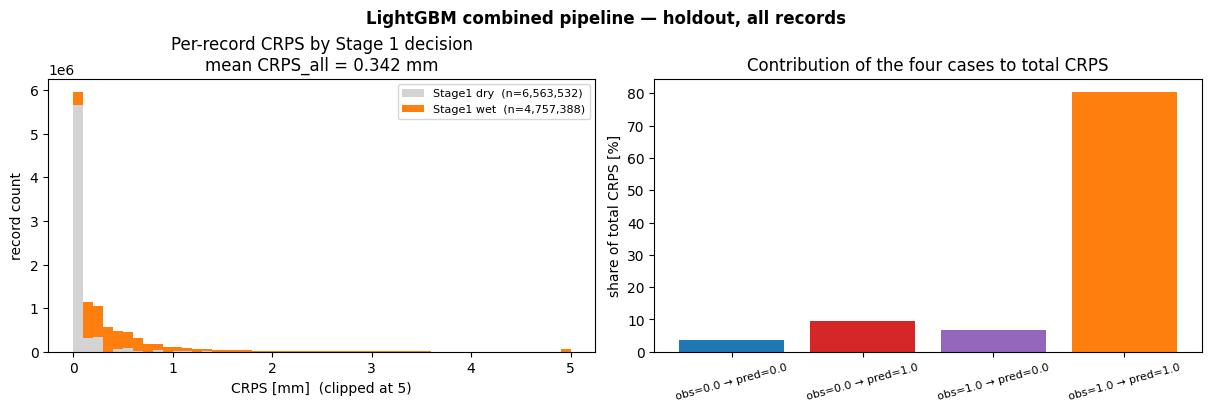

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ax = axes[0]
dry = df_all.loc[df_all['pred_wet'] == 0, 'crps']
wet = df_all.loc[df_all['pred_wet'] == 1, 'crps']
ax.hist([dry.clip(upper=5), wet.clip(upper=5)], bins=50,
         stacked=True, color=['lightgray', 'tab:orange'],
         label=[f'Stage1 dry  (n={len(dry):,})',
                f'Stage1 wet  (n={len(wet):,})'])
ax.set_xlabel('CRPS [mm]  (clipped at 5)')
ax.set_ylabel('record count')
ax.set_title(f'Per-record CRPS by Stage 1 decision\n'
             f'mean CRPS_all = {test_crps:.3f} mm')
ax.legend(fontsize=8)

ax = axes[1]
contrib = (four_cases['crps_sum'] / four_cases['crps_sum'].sum() * 100).reset_index()
labels = [f"obs={r['obs_wet']} → pred={r['pred_wet']}"
          for _, r in contrib.iterrows()]
ax.bar(range(len(contrib)), contrib['crps_sum'],
        color=['tab:blue', 'tab:red', 'tab:purple', 'tab:orange'])
ax.set_xticks(range(len(contrib)))
ax.set_xticklabels(labels, rotation=15, fontsize=8)
ax.set_ylabel('share of total CRPS [%]')
ax.set_title('Contribution of the four cases to total CRPS')

fig.suptitle('LightGBM combined pipeline — holdout, all records',
              fontsize=12, fontweight='bold')
fig.savefig(FIG_DIR / 'all_records_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Next step — Chapter 7

Paste the *All records* row of `all_records_metrics.json` (CRPS = `crps_all_mm`,
MAE = `mae_all_mm`) into the *Gradient boosting — All records* line of
Table~\ref{tab:final-comparison} in `thesis/text/7_comparison.tex`.